# RAINFALL DATASET

# **Import Modules**

In [95]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, auc

from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 

from imblearn.over_sampling import RandomOverSampler
from collections import Counter

from xgboost import XGBClassifier


# **Load The Dataset**

In [96]:
df = pd.read_csv('Rainfall.csv')

# **Data Understanding**

In [97]:
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [98]:
df.isnull().sum()

day                       0
pressure                  0
maxtemp                   0
temparature               0
mintemp                   0
dewpoint                  0
humidity                  0
cloud                     0
rainfall                  0
sunshine                  0
         winddirection    1
windspeed                 1
dtype: int64

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [100]:
df.shape

(366, 12)

In [101]:
df.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [102]:
df.columns.str.strip()

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [103]:
df.columns = df.columns.str.strip()

In [104]:
df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [105]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,366.0,15.756831,8.823592,1.0,8.000,16.00,23.000,31.0
pressure,366.0,1013.742623,6.414776,998.5,1008.500,1013.00,1018.100,1034.6
maxtemp,366.0,26.191257,5.978343,7.1,21.200,27.75,31.200,36.3
temparature,366.0,23.747268,5.632813,4.9,18.825,25.45,28.600,32.4
mintemp,366.0,21.894536,5.594153,3.1,17.125,23.70,26.575,30.0
dewpoint,366.0,19.989071,5.997021,-0.4,16.125,21.95,25.000,26.7
humidity,366.0,80.177596,10.062470,36.0,75.000,80.50,87.000,98.0
cloud,366.0,71.128415,21.798012,0.0,58.000,80.00,88.000,100.0
sunshine,366.0,4.419399,3.934398,0.0,0.500,3.50,8.200,12.1
winddirection,365.0,101.506849,81.723724,10.0,40.000,70.00,190.000,350.0


# **Data Preprocessing**

In [106]:
df['winddirection'].mode()[0]

20.0

In [107]:
df['winddirection'] = df['winddirection'].fillna(df['winddirection'].mode()[0])

df['windspeed'] = df['windspeed'].fillna(df['windspeed'].median())

In [108]:
df.isnull().sum()

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [109]:
df.drop(columns='day', inplace= True)

In [110]:
num_cols = ['pressure', 'dewpoint', 'humidity',
            'cloud', 'sunshine', 'winddirection', 'windspeed']


num_transformer = Pipeline(steps=[
    ('scalar', StandardScaler())

])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols)
    ]
)

# **EDA**

In [111]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

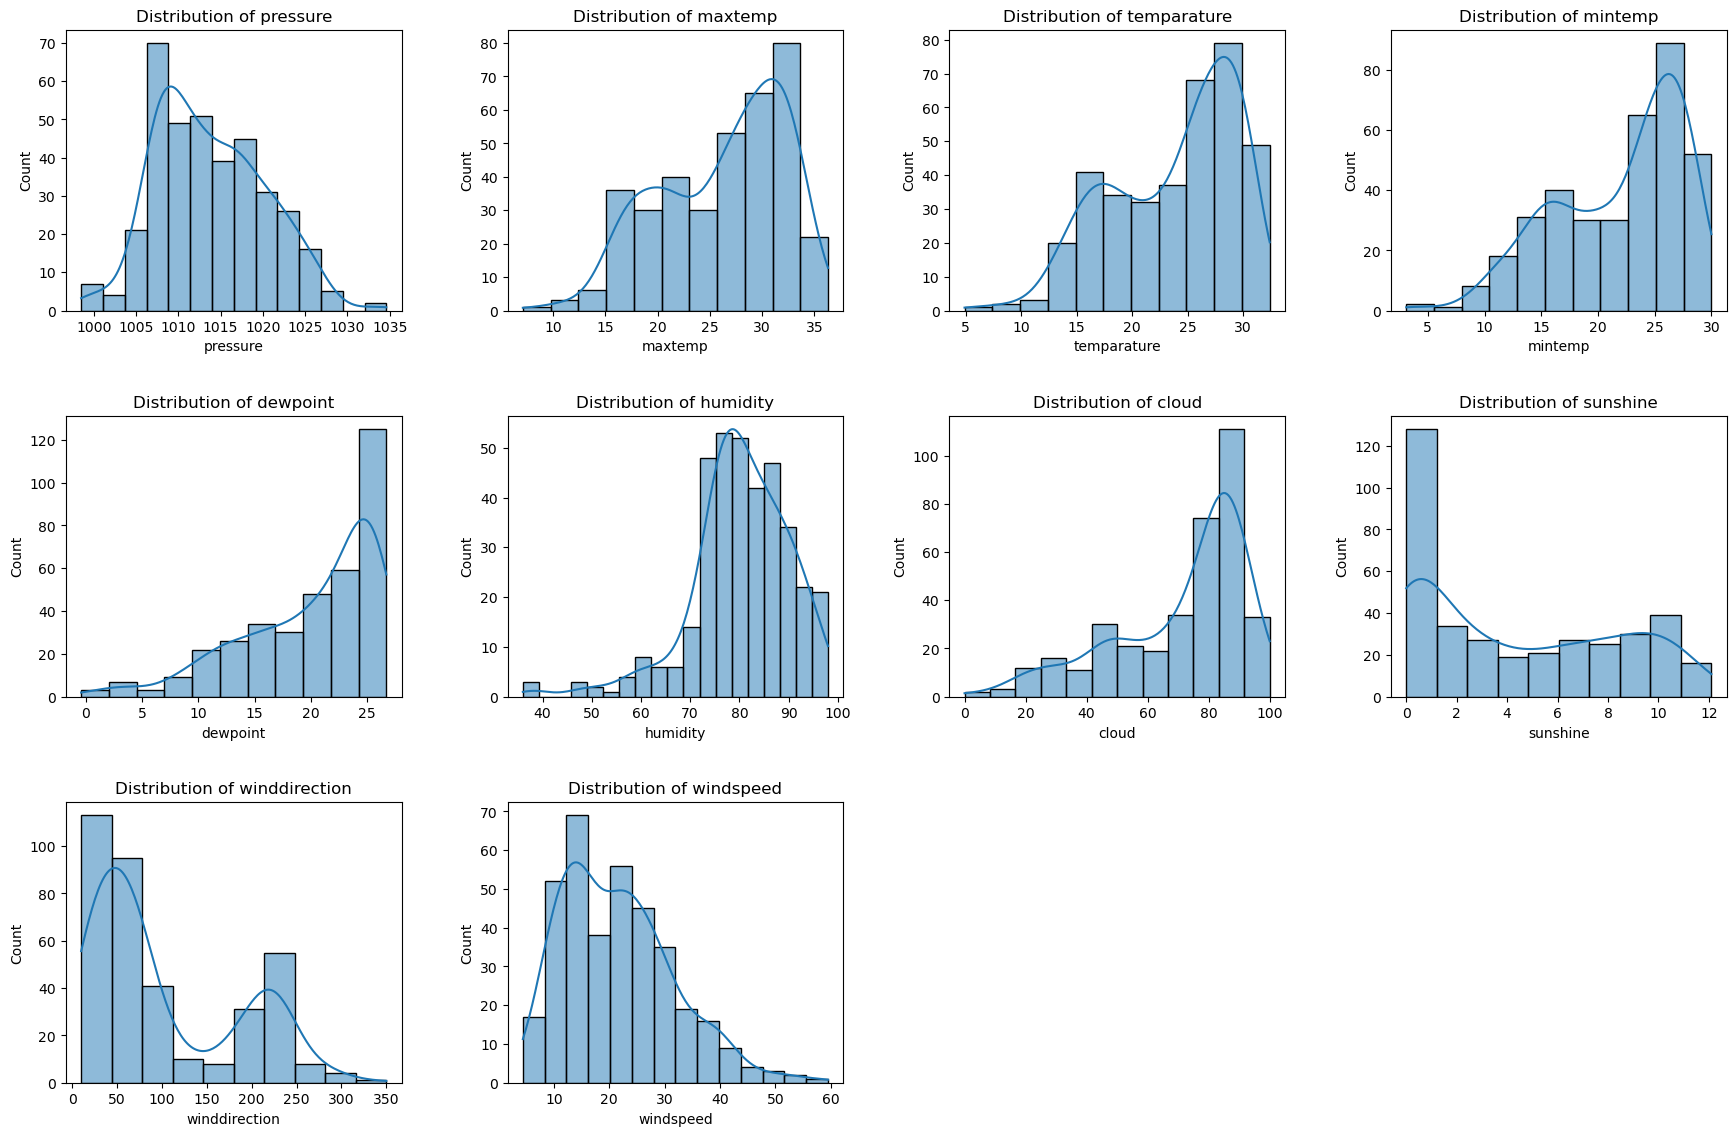

In [112]:
columns = ['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed']

plt.figure(figsize=(18, 12))

for i, column in enumerate(columns, 1):
    plt.subplot(3,4, i)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')

plt.tight_layout(pad=3.0)
plt.show()

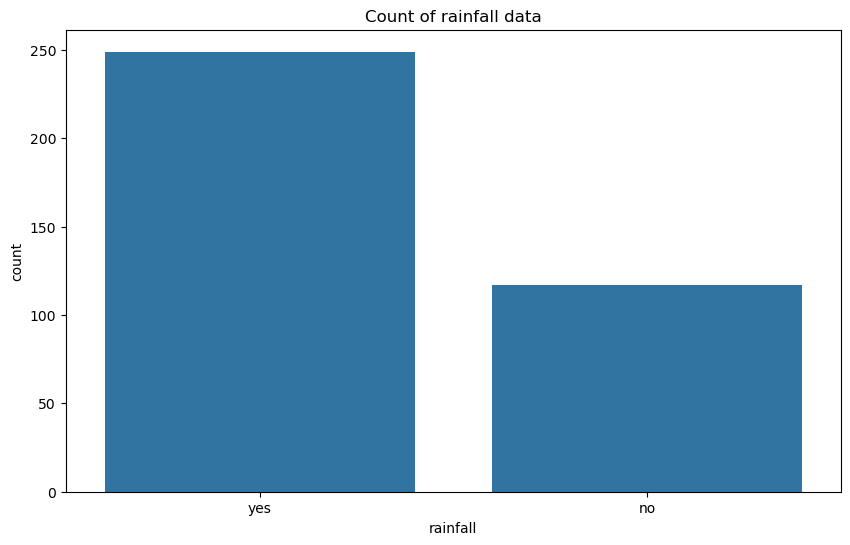

In [113]:
plt.figure(figsize=(10, 6))

sns.countplot(x = 'rainfall', data=df)
plt.title("Count of rainfall data")
plt.show()

In [114]:
df['rainfall'].value_counts()

rainfall
yes    249
no     117
Name: count, dtype: int64

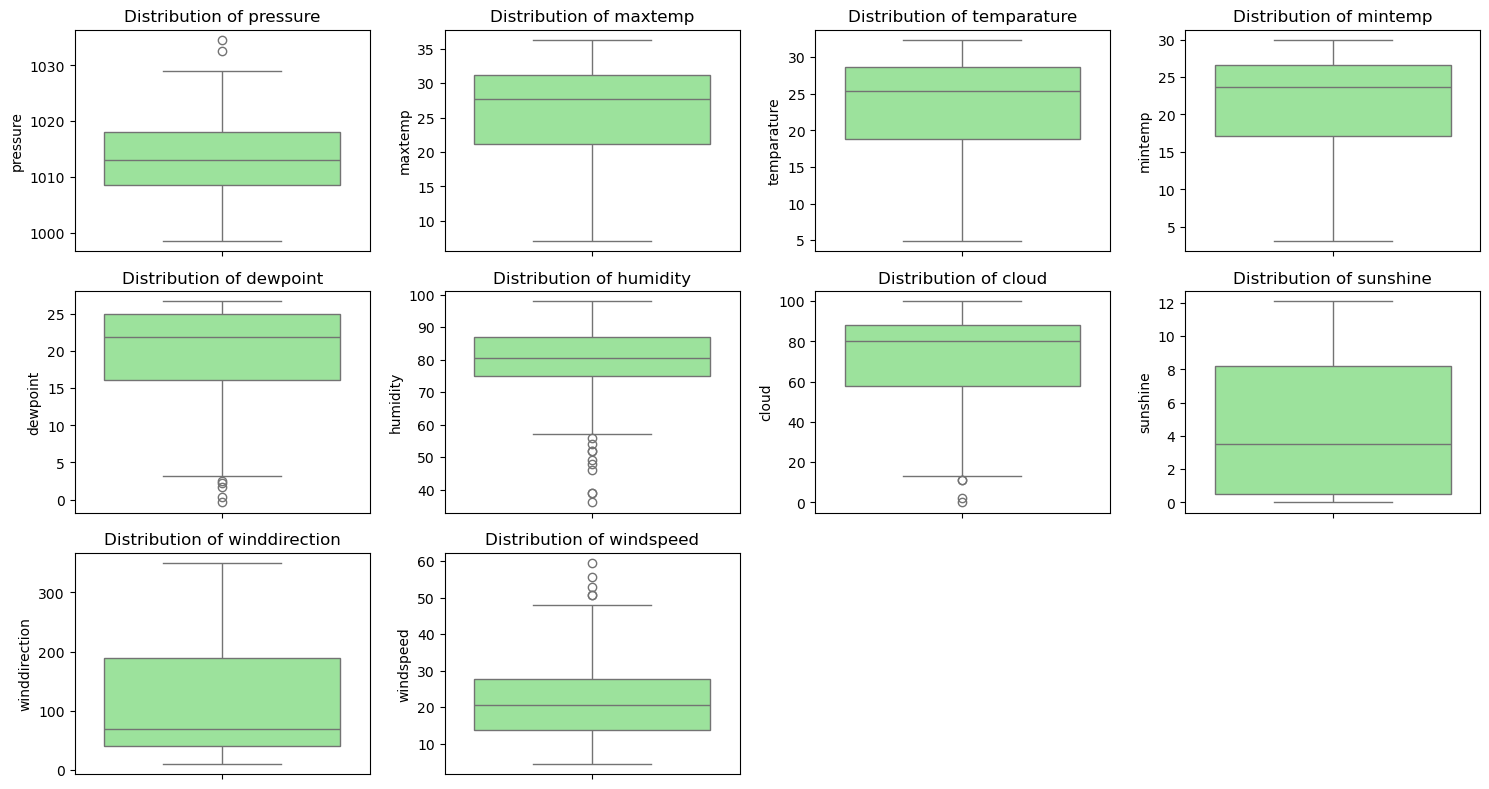

In [115]:
plt.figure(figsize=(15, 8))

for i, column in  enumerate(columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(df[column], color="lightgreen")
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

In [116]:
df['rainfall'].value_counts()

rainfall
yes    249
no     117
Name: count, dtype: int64

In [117]:
le = LabelEncoder()

df['rainfall'] = le.fit_transform(df['rainfall'])

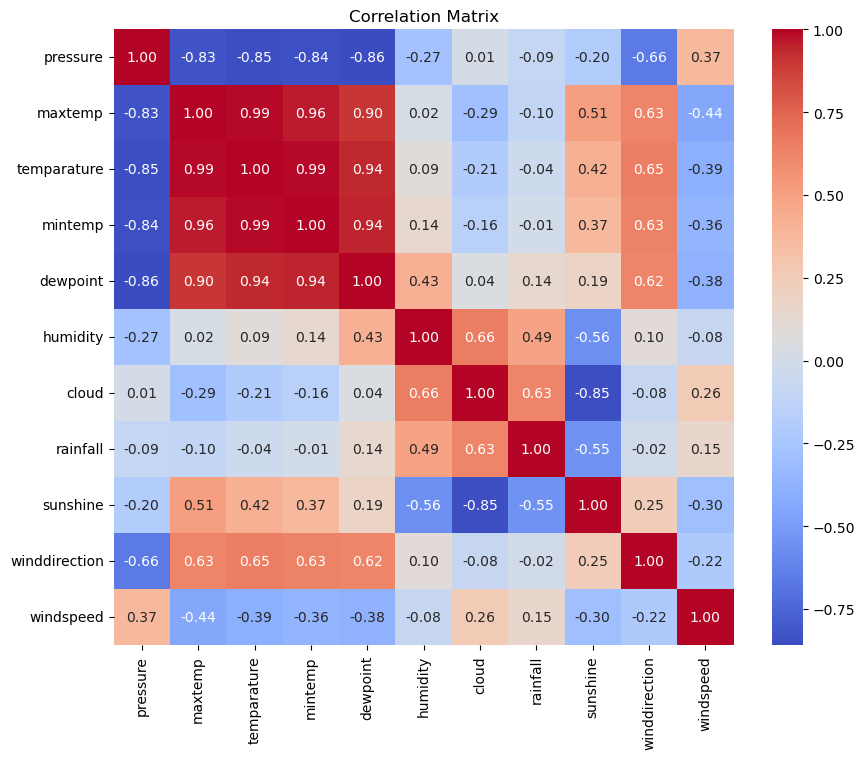

In [118]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(), annot=True, cmap= 'coolwarm', fmt= '.2f')

plt.title("Correlation Matrix")
plt.show()

- Max Temp, temperature, min_temp, dewpoint are highly correlated with each other, so we select only dewpoints to avoid multicollinearity

# Check Imbalance

In [119]:
df['rainfall'].value_counts()

rainfall
1    249
0    117
Name: count, dtype: int64

- since it is small dataset and the data is imbalanced so we apply randomoversampling

# **Model Building**

In [120]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

In [121]:
X = df.drop(columns=['maxtemp', 'temparature', 'mintemp', 'rainfall'])

y = df['rainfall']

# Train-Validation Split

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:
# Check original distribution
print("Before Oversampling:", Counter(y_train))

Before Oversampling: Counter({1: 198, 0: 94})


#  Random Oversampling for Imbalance

In [124]:
# Oversample 

ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

In [125]:
# Check new distribution
print("After Oversampling :", Counter(y_resampled))

After Oversampling : Counter({0: 198, 1: 198})


# **Model Building & Evaluation**


=====LogisticRegression====
ROC-AUC:  0.814
Best Threshold (ROC-J):  0.781

Classification Report (Optimal ROC Threshold):
              precision    recall  f1-score   support

           0       0.54      0.87      0.67        23
           1       0.92      0.67      0.77        51

    accuracy                           0.73        74
   macro avg       0.73      0.77      0.72        74
weighted avg       0.80      0.73      0.74        74

Confusion Matrix:
 [[20  3]
 [17 34]]
CrossVal Accuracy (no threshold tuning): 0.8005 ± 0.0587

=====Random Forest====
ROC-AUC:  0.760
Best Threshold (ROC-J):  0.530

Classification Report (Optimal ROC Threshold):
              precision    recall  f1-score   support

           0       0.68      0.57      0.62        23
           1       0.82      0.88      0.85        51

    accuracy                           0.78        74
   macro avg       0.75      0.72      0.73        74
weighted avg       0.78      0.78      0.78        74

Confusio

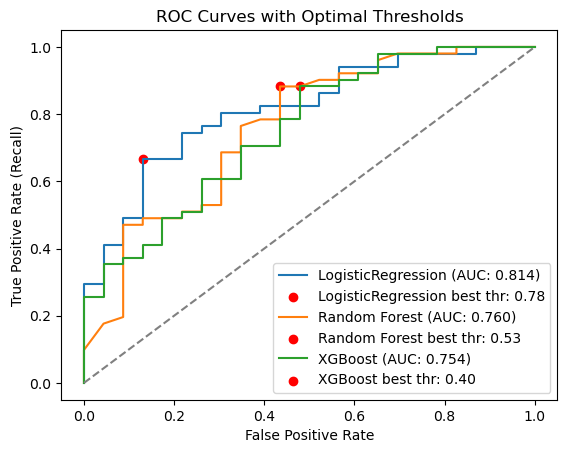

In [135]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, solver='liblinear', penalty='l2', random_state=42), 
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(learning_rate=0.1, max_depth=3, random_state=42)
}

# Optimal Threshold From ROC Curve 

for name, model in models.items(): 

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', model)
    ])

    pipe.fit(X_resampled, y_resampled)

    # Get probailities 

    y_proba = pipe.predict_proba(X_test)[:,1]

    fpr, tpr, threshold = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    # Find best threshold using Youden’s J statistic
    j_scores = tpr - fpr 
    
    best_idx = np.argmax(j_scores)

    best_thres = threshold[best_idx]

    print(f'\n====={name}====')
    print(f'ROC-AUC: {auc: .3f}')
    print(f'Best Threshold (ROC-J): {best_thres: .3f}')

    # Apply optimal Threshold 

    y_pred_opt = (y_proba >= best_thres).astype(int)

    print('\nClassification Report (Optimal ROC Threshold):')
    print(classification_report(y_test, y_pred_opt))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_opt)) 

    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy", n_jobs=-1)
    print("CrossVal Accuracy (no threshold tuning): %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))

    # Plot ROC curve with best threshold point 

    plt.plot(fpr, tpr, label = f'{name} (AUC: {auc:.3f})')
    plt.scatter(fpr[best_idx], tpr[best_idx], marker='o', color ='red', label = f'{name} best thr: {best_thres:.2f}')

# Finalize ROC plot

plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves with Optimal Thresholds")
plt.legend()
plt.show()


In [127]:
cv_scores = cross_val_score(RandomForestClassifier(random_state=42), X, y, cv=5, scoring="accuracy", n_jobs=-1)
print("CrossVal Accuracy (no threshold tuning): %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))

CrossVal Accuracy (no threshold tuning): 0.7595 ± 0.0326


# Final Model Training & Prediction

In [128]:
final_pipe = Pipeline([
    ('preprocessor', preprocessor), 
    ('clf', LogisticRegression(max_iter=1000,solver='liblinear', penalty='l2', random_state=42))
])

In [129]:
# Fit on entire dataset with oversampling
X_res_full, y_res_full = ros.fit_resample(X, y)


In [130]:
final_pipe.fit(X_res_full, y_res_full)


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Predict on Entire Dataset (optional)

In [131]:
# Predictions on full training dataset (oversampled)
y_proba_full = final_pipe.predict_proba(X_res_full)[:,1]

# Apply optimal threshold
# final_preds = (y_proba_full >= best_thres).astype(int)
y_pred_thresh = (y_proba_full >= best_thres).astype(int)


# Accuracy
print("Accuracy on full dataset (threshold method):", accuracy_score(y_res_full, y_pred_thresh))

Accuracy on full dataset (threshold method): 0.785140562248996


In [132]:
print("\nClassification Report:\n", classification_report(y_res_full, y_pred_thresh))
print("\nConfusion Matrix:\n", confusion_matrix(y_res_full, y_pred_thresh))


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.71      0.77       249
           1       0.75      0.86      0.80       249

    accuracy                           0.79       498
   macro avg       0.79      0.79      0.78       498
weighted avg       0.79      0.79      0.78       498


Confusion Matrix:
 [[177  72]
 [ 35 214]]


In [133]:
# Predict using default 0.5 threshold
y_pred_default = final_pipe.predict(X_res_full)

# Accuracy
print("Accuracy on full dataset (default threshold (0.5) predict):", accuracy_score(y_res_full, y_pred_default))

Accuracy on full dataset (default threshold (0.5) predict): 0.7730923694779116


In [134]:
print("\nClassification Report (direct predict):\n", classification_report(y_res_full, y_pred_default))
print("Confusion Matrix (direct predict):\n", confusion_matrix(y_res_full, y_pred_default))


Classification Report (direct predict):
               precision    recall  f1-score   support

           0       0.79      0.74      0.77       249
           1       0.76      0.81      0.78       249

    accuracy                           0.77       498
   macro avg       0.77      0.77      0.77       498
weighted avg       0.77      0.77      0.77       498

Confusion Matrix (direct predict):
 [[184  65]
 [ 48 201]]
